Total bytes: 20132659200
Possible shape (19200, 512, 512) with dtype=<class 'numpy.float32'> order=C


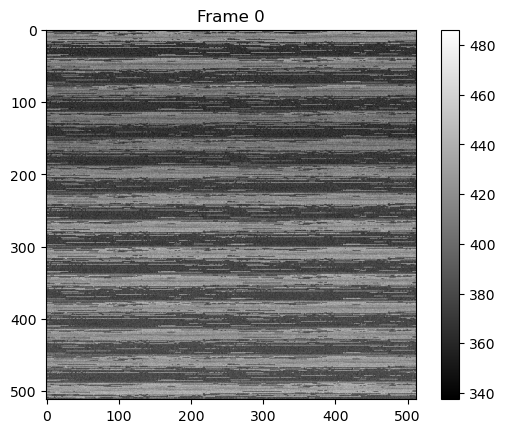

Possible shape (19200, 512, 512) with dtype=<class 'numpy.float32'> order=F


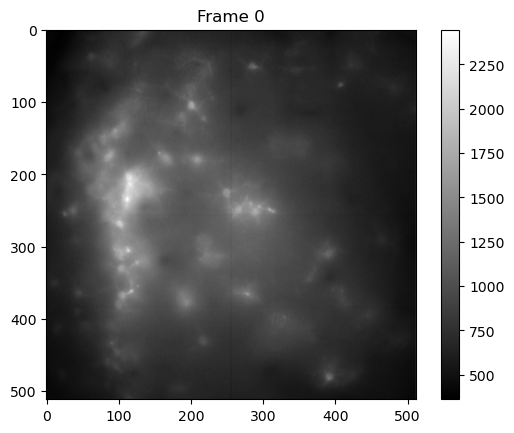

In [18]:
import mmap
import numpy as np
import matplotlib.pyplot as plt

def open_mmap(path):
    f = open(path, "rb")
    mm = mmap.mmap(f.fileno(), length=0, access=mmap.ACCESS_READ)
    return f, mm

def try_infer_shape(mm, w, h, dtype=np.float32, order='C'):
    """
    Try reshaping memory into (n_frames, h, w).
    Returns array view or None if not possible.
    """
    dtype_size = np.dtype(dtype).itemsize
    total_bytes = mm.size()
    frame_size = w * h * dtype_size
    if total_bytes % frame_size != 0:
        return None
    n_frames = total_bytes // frame_size
    arr = np.ndarray((n_frames, h, w), 
                     buffer=mm, dtype=dtype, order=order)
    return arr

def show_frame(arr, idx=0):
    """Show a frame using matplotlib."""
    plt.imshow(arr[idx], cmap='gray')
    plt.title(f"Frame {idx}")
    plt.colorbar()
    plt.show()


if __name__ == "__main__":
   #path = r'C:\Users\ICNLab\caiman_data\testdata\testdata\FOV1_T2new\memmap__d1_512_d2_512_d3_1_order_C_frames_12800.mmap'  #--> shape (12800, 512, 512) with dtype=<class 'numpy.float32'> order=F
    path = r'R:\FOV1_T1_rig__d1_512_d2_512_d3_1_order_C1_frames_19200.mmap'  #--> Possible shape (12800, 512, 512) with dtype=<class 'numpy.float32'> order=F

    f, mm = open_mmap(path)
    print("Total bytes:", mm.size())

    # Try different guesses:
    candidates = [
        (512, 512, np.float32, 'C'),
        (512, 512, np.float32, 'F'),
    ]

    for w, h, dtype, order in candidates:
        arr = try_infer_shape(mm, w, h, dtype, order)
        if arr is not None:
            print(f"Possible shape {arr.shape} with dtype={dtype} order={order}")
            show_frame(arr, 0)

    mm.close()
    f.close()


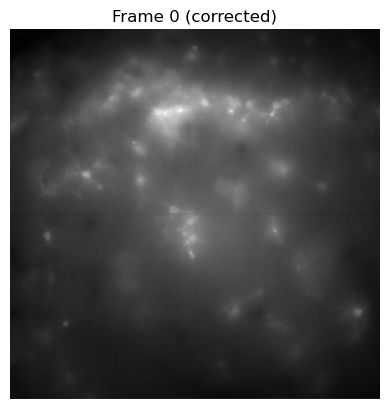

In [9]:
import mmap
import numpy as np
import matplotlib.pyplot as plt

path = r'R:\FOV1_T1_rig__d1_512_d2_512_d3_1_order_C_frames_19200.mmap'

with open(path, "rb") as f:
    mm = mmap.mmap(f.fileno(), 0, access=mmap.ACCESS_READ)

    n_frames = mm.size() // (512 * 512 * 4)  # float32 = 4 bytes
    arr = np.ndarray((n_frames, 512, 512), buffer=mm, dtype=np.float32, order='C')

    plt.imshow(np.rot90(arr[0][::-1, :], -1), cmap='gray')
    plt.title("Frame 0 (corrected)")
    plt.axis("off")
    plt.show()

    mm.close()


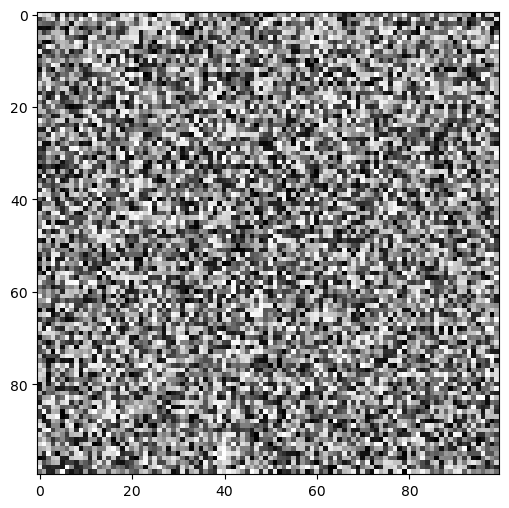

In [ ]:
# ##
# # print("Loading stabilized movie from RAM-disk...")
# # # Path to RAM disk memmap
# # p = Path(fname)
# # ram_path = Path(r'R:/') / f"{p.stem}_rig__d1_{m_rig.shape[1]}_d2_{m_rig.shape[2]}_d3_1_order_C_frames_{m_rig.shape[0]}.mmap"
# # ram_path = str(ram_path).replace("/", "\\")
# # print("RAM path:", ram_path)
# ram_path = r'R:\FOV1_T1_rig__d1_512_d2_512_d3_1_order_C1_frames_19200.mmap'   

# with open(ram_path, "rb") as f:
#     mm = mmap.mmap(f.fileno(), 0, access=mmap.ACCESS_READ)

#     n_frames = mm.size() // (512 * 512 * 4)  # float32 = 4 bytes
#     arr = np.ndarray((n_frames, 512, 512), buffer=mm, dtype=np.float32, order='F')

#     # Copy the data into memory
#     m_rig = np.array(arr, copy=True)

#     # Display the first frame with the orientation fix
#     plt.imshow(np.rot90(m_rig[0][::-1, :], -1), cmap='gray')
#     plt.title("Frame 0 (loaded into memory)")
#     plt.axis("off")
#     plt.show()

#     mm.close()

# # Now m_rig is fully in memory
# print("Movie loaded into memory. Shape:", m_rig.shape)







# ram_path = r'R:\FOV1_T1_rig__d1_512_d2_512_d3_1_order_C1_frames_19200.mmap'   

# with open(ram_path, "rb") as f:
#     mm = mmap.mmap(f.fileno(), 0, access=mmap.ACCESS_READ)

#     n_frames = mm.size() // (512 * 512 * 4)  # float32 = 4 bytes
#     arr = np.ndarray((n_frames, 512, 512), buffer=mm, dtype=np.float32, order='F')

#     # Copy the data into memory
#     m_rig = np.array(arr, copy=True)

#     # Display the first frame with the orientation fix
#     plt.imshow(np.rot90(m_rig[0][::-1, :], -1), cmap='gray')
#     plt.title("Frame 0 (loaded into memory)")
#     plt.axis("off")
#     plt.show()

#     mm.close()

# # Now m_rig is fully in memory
# print("Movie loaded into memory. Shape:", m_rig.shape)



# import mmap
# import numpy as np
# import matplotlib.pyplot as plt

# path = r'R:\FOV1_T1_rig__d1_512_d2_512_d3_1_order_C1_frames_19200.mmap'

# with open(path, "rb") as f:
#     mm = mmap.mmap(f.fileno(), 0, access=mmap.ACCESS_READ)

#     n_frames = mm.size() // (512 * 512 * 4)  # float32 = 4 bytes
#     arr = np.ndarray((n_frames, 512, 512), buffer=mm, dtype=np.float32, order='F')

#     plt.imshow(np.rot90(m_rig[0][::-1, :], -1), cmap='gray')
#     plt.title("Frame 0 (corrected)")
#     plt.axis("off")
#     plt.show()

#     mm.close()

